In [48]:
#1.IMPORT LIBRARIES

In [7]:
import pandas as pd

In [47]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [1]:
import os

In [ ]:
#2.LOAD DATASET SAMPLE

In [3]:
file = r"C:\Users\tahni\Downloads\archive\2019-Oct.csv"

In [4]:
size_gb = os.path.getsize(file) / (1024**3)

In [5]:
print(f"File size: {size_gb:.2f} GB")

File size: 5.28 GB


In [8]:
df = pd.read_csv(
    r"C:\Users\tahni\Downloads\archive\2019-Oct.csv",
    nrows=100000
)

In [9]:
print(df.shape)

(100000, 9)


In [10]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [ ]:
#3. DATA UNDERSTANDING

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     100000 non-null  datetime64[ns, UTC]
 1   event_type     100000 non-null  object             
 2   product_id     100000 non-null  int64              
 3   category_id    100000 non-null  int64              
 4   category_code  100000 non-null  object             
 5   brand          100000 non-null  object             
 6   price          100000 non-null  float64            
 7   user_id        100000 non-null  int64              
 8   user_session   100000 non-null  object             
 9   hour           100000 non-null  int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(3), object(4)
memory usage: 7.2+ MB


In [50]:
df.describe()

,product_id,category_id,price,user_id,hour
count,1.000000e+05,1.000000e+05,100000.000000,1.000000e+05,100000.00000
mean,1.029819e+07,2.056094e+18,286.827664,5.310909e+08,3.00124
std,1.113546e+07,1.490982e+16,360.304691,1.662030e+07,0.77213
min,1.001588e+06,2.053014e+18,0.000000,3.064418e+08,0.00000
25%,1.005124e+06,2.053014e+18,61.010000,5.156360e+08,3.00000
50%,5.100580e+06,2.053014e+18,154.380000,5.269649e+08,3.00000
75%,1.590169e+07,2.053014e+18,357.110000,5.477189e+08,4.00000
max,5.310002e+07,2.175420e+18,2574.070000,5.554835e+08,4.00000


In [51]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session', 'hour'],
      dtype='object')

In [52]:
#4.CHECK MISSING VALUES

In [11]:
df.isnull().sum()

event_time           0
event_type           0
product_id           0
category_id          0
category_code    32587
brand            14393
price                0
user_id              0
user_session         0
dtype: int64

In [27]:
#Calculate Missing Percentage

In [28]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

event_time        0.000
event_type        0.000
product_id        0.000
category_id       0.000
category_code    32.587
brand            14.393
price             0.000
user_id           0.000
user_session      0.000
hour              0.000
dtype: float64


In [29]:
#Visualize Missing Values

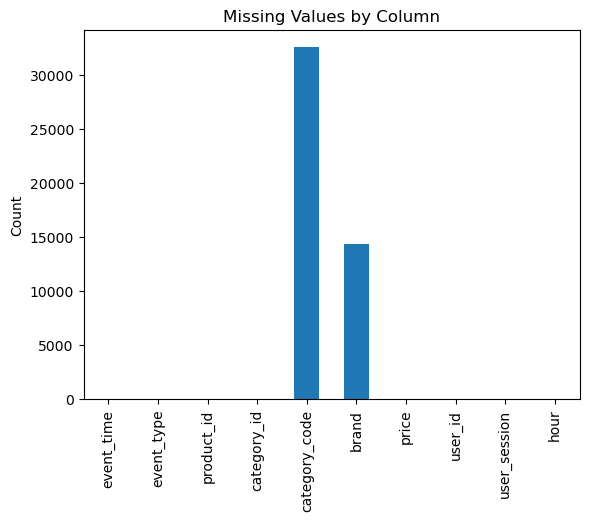

In [31]:
missing = df.isnull().sum()
missing.plot(kind='bar')

plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.show()

In [ ]:
#5. DATA CLEANING

In [36]:
#Replace with "Unknown"

In [33]:
df['brand'] = df['brand'].fillna('Unknown')
df['category_code'] = df['category_code'].fillna('Unknown')

In [35]:
#Checking again for null

In [37]:
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
hour             0
dtype: int64

In [53]:
#6. Exploratory Data Analysis (EDA)

In [17]:
#Event Type Distribution

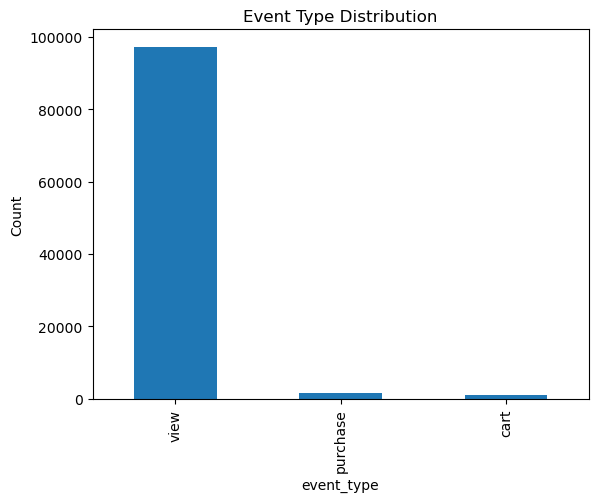

In [38]:
df['event_type'].value_counts().plot(kind='bar')

plt.title('Event Type Distribution')
plt.ylabel('Count')
plt.show()

In [41]:
#Top 10 Brands

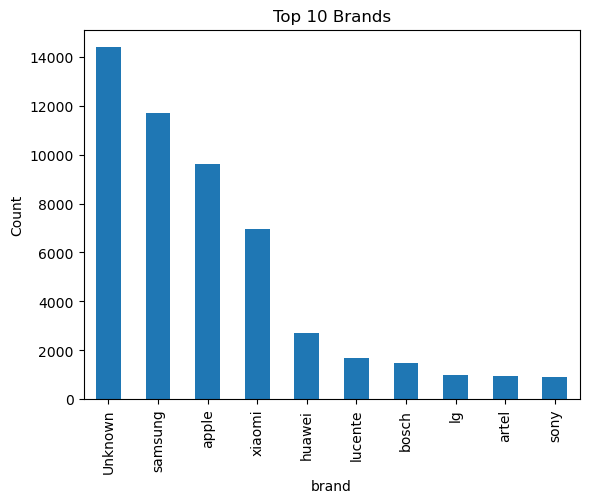

In [39]:
top_brands = df['brand'].value_counts().head(10)

top_brands.plot(kind='bar')

plt.title('Top 10 Brands')
plt.ylabel('Count')
plt.show()

In [19]:
#Price Distribution

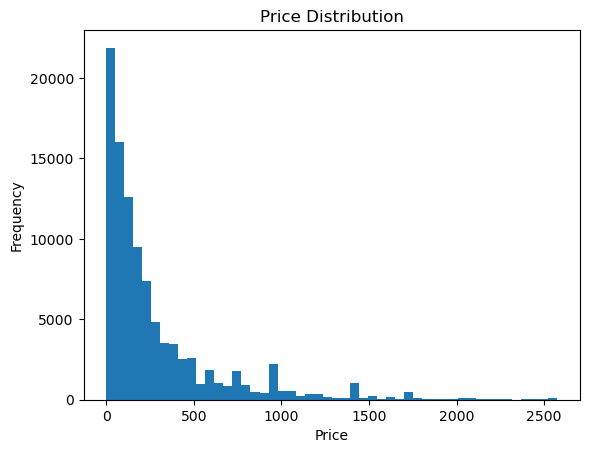

In [42]:
plt.hist(df['price'].dropna(), bins=50)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [20]:
#Top 10 Categories

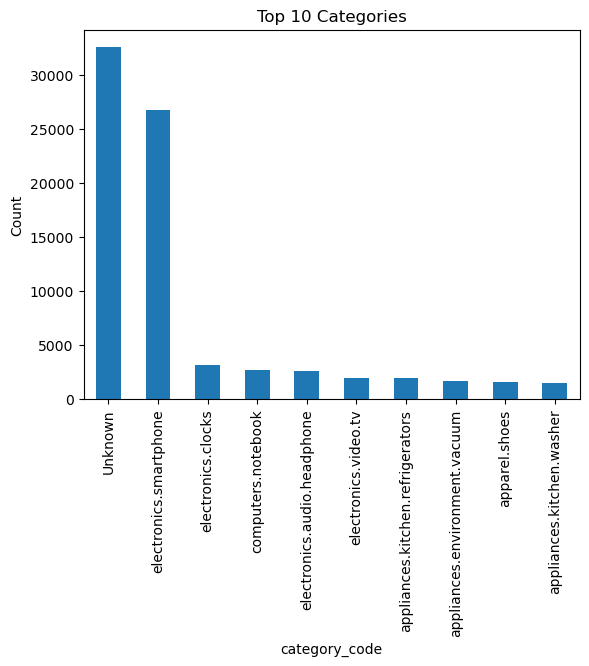

In [43]:
top_categories = df['category_code'].value_counts().head(10)

top_categories.plot(kind='bar')

plt.title('Top 10 Categories')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [21]:
#Most Expensive Products

In [45]:
df[['product_id', 'brand', 'price']].sort_values(
    by='price',
    ascending=False
).head(10)

,product_id,brand,price
4151,21407288,rado,2574.07
65225,21407287,rado,2574.07
34441,21407287,rado,2574.07
39443,1801804,lg,2574.04
39089,1801804,lg,2574.04
87768,1307275,msi,2574.04
52970,1307275,msi,2574.04
9545,1307275,msi,2574.04
53771,1307275,msi,2574.04
10059,1307275,msi,2574.04


In [24]:
#Convert Time Column

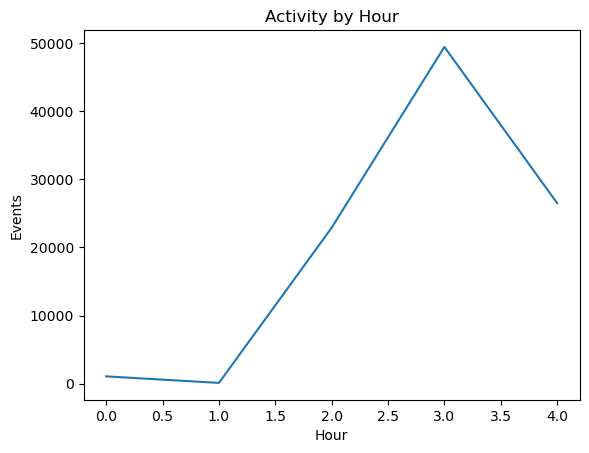

In [46]:
df['event_time'] = pd.to_datetime(df['event_time'])

df['hour'] = df['event_time'].dt.hour

df['hour'].value_counts().sort_index().plot(kind='line')

plt.title('Activity by Hour')
plt.xlabel('Hour')
plt.ylabel('Events')
plt.show()

In [54]:
#7. Time-Based Analysis

In [55]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [56]:
df['hour'] = df['event_time'].dt.hour

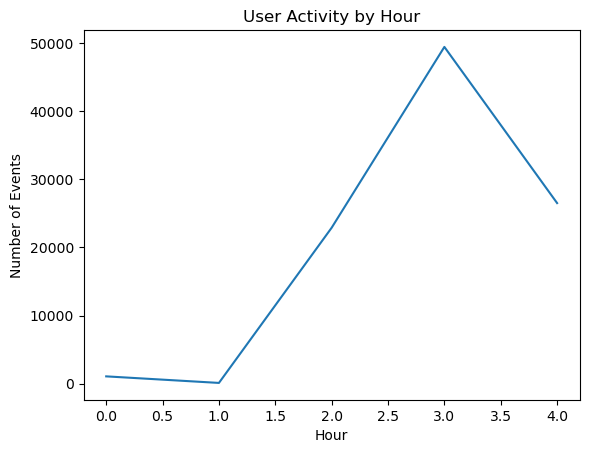

In [57]:
hourly = df['hour'].value_counts().sort_index()

hourly.plot(kind='line')
plt.title('User Activity by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Events')
plt.show()

In [58]:
#8. Feature Engineering

In [59]:
df['purchase'] = np.where(
    df['event_type'] == 'purchase',
    1,
    0
)

In [60]:
df['purchase'].value_counts()

purchase
0    98345
1     1655
Name: count, dtype: int64

In [61]:
#9. Machine Learning Model

In [62]:
features = df[['price']]
target = df['purchase']

In [63]:
#Split data:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [64]:
#Train model:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
#Predict:
predictions = model.predict(X_test)

In [66]:
#Evaluate:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9816


In [67]:
print("Actual:")
print(y_test.head())

print("Predicted:")
print(predictions[:5])

Actual:
75721    0
80184    0
19864    0
76699    0
92991    1
Name: purchase, dtype: int64
Predicted:
[0 0 0 0 0]
